# Data Visualization with pandas and seaborn 📈

### ISA 383: Python for Business Analytics

A chart is useful when it helps someone see and discuss a pattern. This notebook follows a
table-first workflow: ask a question, calculate a summary table, choose a suitable chart,
and then write a careful interpretation.


## Using this notebook in Google Colab

1. Before editing, select **File > Save a copy in Drive**.
2. Run the cells in order. Some practice cells intentionally wait for your input.
3. The notebook creates any course folders and teaching files it needs automatically.
4. Files under `/content` are temporary and disappear when the Colab runtime resets.
5. Never paste an API key into a notebook cell. Use the **Secrets** panel when instructed.

You do not need to find, copy, or type a file path for the prepared course data.


## Learning objectives 🎯

By the end of this notebook, you should be able to:

1. Match common chart types to categorical, continuous, and time-based variables.
2. Build charts with pandas, seaborn, and matplotlib.
3. Start with a summary table before plotting.
4. Label units, denominators, and comparison groups clearly.
5. State an evidence-based interpretation without turning association into causation.


## 1. Load the data and choose a chart 🧭

We use the same compact Dubai weather file as the pandas and cleaning notebooks. Reusing the
file reduces context switching and lets us focus on the analytical question.

| Question | Variable pattern | Useful first chart |
|---|---|---|
| How did temperature change over time? | Date + numeric | Line chart |
| How are values distributed? | Numeric | Histogram or box plot |
| How many observations are in each group? | Categorical | Bar chart |
| Are two numeric measures associated? | Numeric + numeric | Scatter plot |


### 🧭 Syntax first: Loading data and creating plotting columns

Read the pattern before running the example. The names in the pattern are placeholders.

```python
pd.read_csv(filepath, parse_dates=["date"])
df.assign(new_column=expression)
df["date"].dt.day_name()
```

Documentation: [read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) · [assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html) · [datetime properties](https://pandas.pydata.org/docs/user_guide/basics.html#basics-dt-accessors)


In [ ]:
from pathlib import Path

import pandas as pd
from IPython.display import display

WEATHER_CSV = "date,station_id,city,temp_max_c,temp_min_c,precipitation_mm,wind_max_kmh\n2025-01-01,DXB,Dubai,25.0,18.4,0.70,21.7\n2025-01-02,DXB,Dubai,22.6,19.9,0.00,26.1\n2025-01-03,DXB,Dubai,21.5,17.6,0.00,17.3\n2025-01-04,DXB,Dubai,22.9,13.0,0.00,14.5\n2025-01-05,DXB,Dubai,22.8,15.6,0.00,13.1\n2025-01-06,DXB,Dubai,25.1,12.5,0.00,16.5\n2025-01-07,DXB,Dubai,25.8,14.3,0.00,13.8\n2025-01-08,DXB,Dubai,24.1,14.0,0.00,9.9\n2025-01-09,DXB,Dubai,22.5,18.0,0.40,11.8\n2025-01-10,DXB,Dubai,24.8,14.2,0.00,15.0\n2025-01-11,DXB,Dubai,26.9,13.5,0.00,15.7\n2025-01-12,DXB,Dubai,24.9,13.8,0.00,10.6\n2025-01-13,DXB,Dubai,23.2,17.3,1.90,18.6\n2025-01-14,DXB,Dubai,23.5,19.6,0.10,13.6\n\n"
DATA_DIR = Path("/content/isa383/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_FILE = DATA_DIR / "uae_weather_daily.csv"
DATA_FILE.write_text(WEATHER_CSV, encoding="utf-8")

weather = pd.read_csv(DATA_FILE, parse_dates=["date"])
display(weather.head())


The examples use a frozen, fourteen-day Dubai weather extract. The values were retrieved
from the Open-Meteo Historical Weather API for 1-14 January 2025 and stored locally so
that every student runs the same file. The file is small enough to inspect directly, but
still has dates, numeric measures, a key, units, and missing-data decisions to discuss.

Source: https://archive-api.open-meteo.com/v1/archive
Location: Dubai, UAE (approximately 25.20 N, 55.30 E)


> 💭 **Quick thought question:** What could a chart show here that a five-row table would make difficult to see?


## 2. Question 1: How did temperature change over time? 🌡️

First inspect the table. Then use a line chart because date order matters.


### 🧭 Syntax first: Line charts

Read the pattern before running the example. The names in the pattern are placeholders.

```python
df.plot(
    x="date",
    y=["value_a", "value_b"],
    kind="line",
    marker="o",
    figsize=(8, 4),
)

sns.lineplot(data=df, x="date", y="value", hue="group", marker="o")
```

Documentation: [DataFrame.plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) · [seaborn.lineplot](https://seaborn.pydata.org/generated/seaborn.lineplot.html)


In [2]:
daily_temperature = weather[["date", "temp_max_c", "temp_min_c"]]
daily_temperature.head()


Out[0]: 
        date  temp_max_c  temp_min_c
0 2025-01-01        25.0        18.4
1 2025-01-02        22.6        19.9
2 2025-01-03        21.5        17.6
3 2025-01-04        22.9        13.0
4 2025-01-05        22.8        15.6


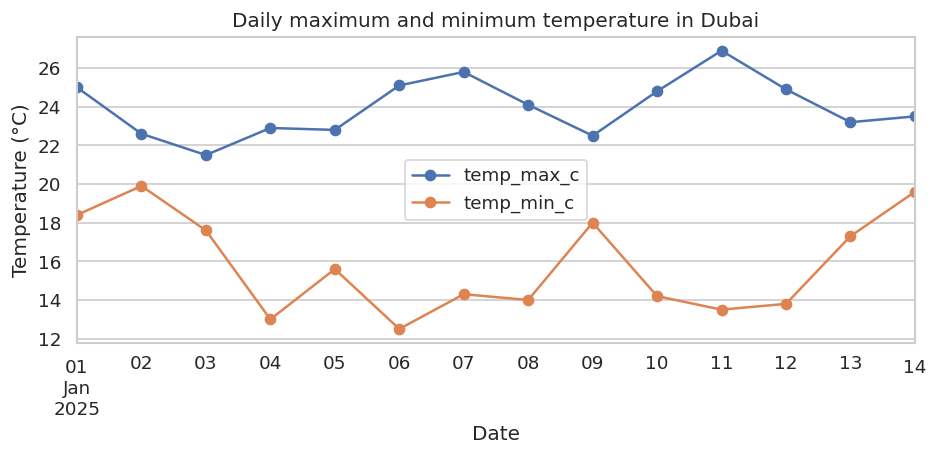

In [3]:
ax = weather.plot(
    x="date",
    y=["temp_max_c", "temp_min_c"],
    marker="o",
    figsize=(8, 4),
    title="Daily maximum and minimum temperature in Dubai",
)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()


> 💭 **Quick thought question:** Does this chart support a statement about Dubai's climate in general, or only this fourteen-day window?


## 3. Question 2: How are temperatures distributed? 📦

A histogram shows the shape of a numeric variable. A box plot emphasizes the median, spread,
and unusual values. Both are descriptive views of this small sample.


### 🧭 Syntax first: Histograms and box plots

Read the pattern before running the example. The names in the pattern are placeholders.

```python
sns.histplot(
    data=df,
    x="numeric_column",
    bins=10,
    stat="count",
    kde=False,
)

sns.boxplot(
    data=df,
    x="numeric_column",
    whis=1.5,
)
```

Documentation: [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) · [boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html)


In [4]:
weather["temp_max_c"].describe().round(1)


Out[0]: 
count    14.0
mean     24.0
std       1.5
min      21.5
25%      22.8
50%      23.8
75%      25.0
max      26.9
Name: temp_max_c, dtype: float64


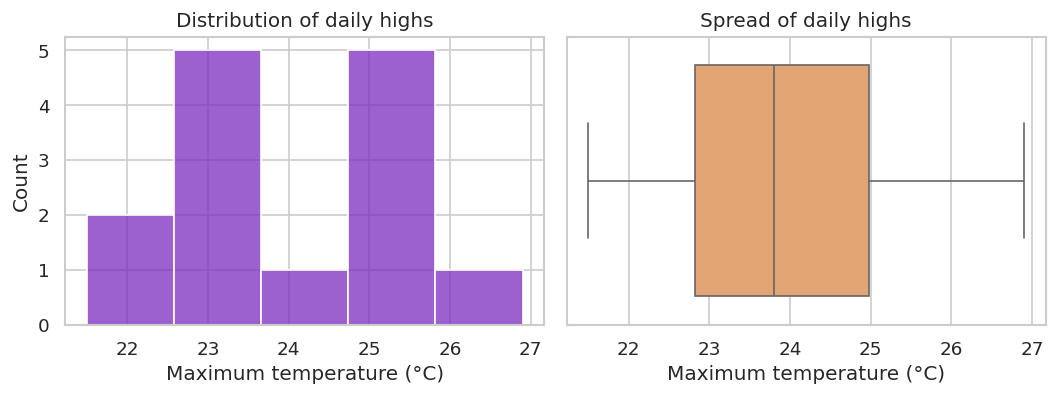

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

sns.histplot(data=weather, x="temp_max_c", bins=5, ax=axes[0], color="#7b2cbf")
axes[0].set_title("Distribution of daily highs")
axes[0].set_xlabel("Maximum temperature (°C)")

sns.boxplot(data=weather, x="temp_max_c", ax=axes[1], color="#f4a261")
axes[1].set_title("Spread of daily highs")
axes[1].set_xlabel("Maximum temperature (°C)")

plt.tight_layout()
plt.show()


> 💭 **Quick thought question:** With only fourteen observations, how much confidence should we place in the apparent shape of the distribution?


## 4. Question 3: How often did rain occur? ☔

Counts and rates answer different questions. Here, the denominator is the number of days in
the file, not the number of millimetres of rain.


### 🧭 Syntax first: Counts and grouped summaries

Read the pattern before running the example. The names in the pattern are placeholders.

```python
df.groupby("group", as_index=False).agg(
    rows=("id", "size"),
    non_missing=("value", "count"),
    average=("value", "mean"),
)

df["group"].value_counts(dropna=False)
```

Documentation: [groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) · [agg](https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.agg.html) · [value_counts](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html)


In [6]:
rain_summary = (
    weather.groupby("rainy", as_index=False)
    .agg(days=("date", "size"), total_rain_mm=("precipitation_mm", "sum"))
)
rain_summary["share_of_days"] = rain_summary["days"] / len(weather)
rain_summary.round(2)


Out[0]: 
   rainy  days  total_rain_mm  share_of_days
0  False    10            0.0           0.71
1   True     4            3.1           0.29


### 🧭 Syntax first: Bar charts

Read the pattern before running the example. The names in the pattern are placeholders.

```python
sns.barplot(
    data=summary,
    x="group",
    y="value",
    estimator=np.mean,
    errorbar=None,
    ax=ax,
)
```

Documentation: [barplot](https://seaborn.pydata.org/generated/seaborn.barplot.html)


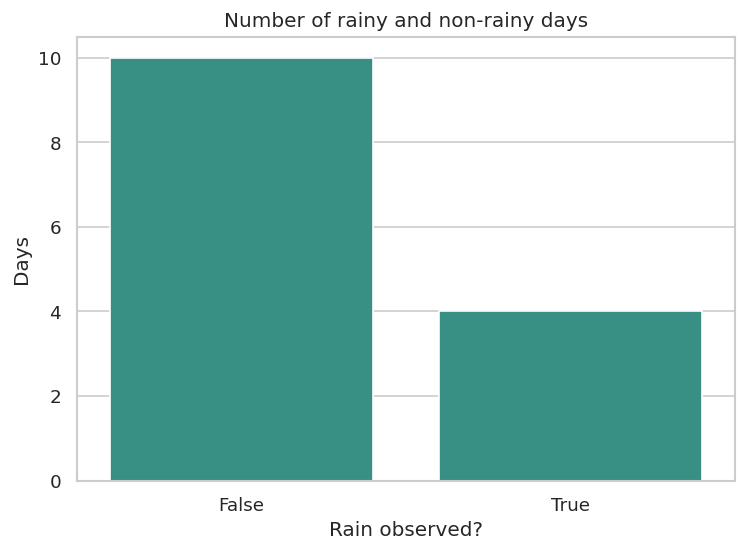

In [7]:
ax = sns.barplot(data=rain_summary, x="rainy", y="days", color="#2a9d8f")
ax.set_title("Number of rainy and non-rainy days")
ax.set_xlabel("Rain observed?")
ax.set_ylabel("Days")
plt.tight_layout()
plt.show()


> 💭 **Quick thought question:** Why is a bar chart of days better than a pie chart for this question? What information would a count alone hide?


## 5. Question 4: Are wind and precipitation associated? 💨

A scatter plot is a useful first view for two numeric variables. The color separates rainy and
non-rainy days, but it does not prove that wind causes rain.


### 🧭 Syntax first: Scatter plots

Read the pattern before running the example. The names in the pattern are placeholders.

```python
sns.scatterplot(
    data=df,
    x="numeric_x",
    y="numeric_y",
    hue="group",
    style="group",
    size="optional_size",
    ax=ax,
)
```

Documentation: [scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html)


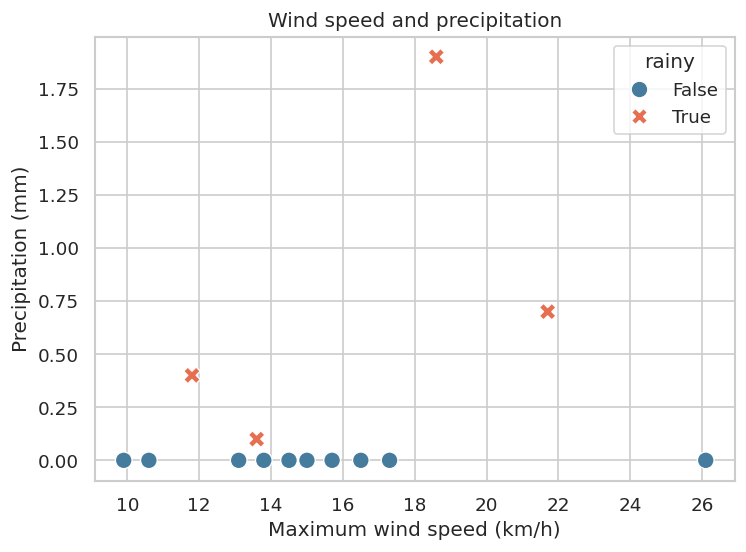

In [8]:
ax = sns.scatterplot(
    data=weather,
    x="wind_max_kmh",
    y="precipitation_mm",
    hue="rainy",
    style="rainy",
    s=100,
    palette={False: "#457b9d", True: "#e76f51"},
)
ax.set_title("Wind speed and precipitation")
ax.set_xlabel("Maximum wind speed (km/h)")
ax.set_ylabel("Precipitation (mm)")
plt.tight_layout()
plt.show()


> 💭 **Quick thought question:** What additional data would you want before making a business decision based on this relationship?


## 6. Question 5: Do weekdays look different? 📅

A grouped summary helps us avoid comparing bars without knowing the underlying values.


### 🧭 Syntax first: Sorting and rounding a summary

Read the pattern before running the example. The names in the pattern are placeholders.

```python
summary.sort_values("average_value", ascending=False).round(1)
```

Documentation: [sort_values](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html) · [round](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.round.html)


In [9]:
weekday_summary = (
    weather.groupby("day_name", as_index=False)
    .agg(
        average_high_c=("temp_max_c", "mean"),
        average_wind_kmh=("wind_max_kmh", "mean"),
        days=("date", "size"),
    )
    .sort_values("average_high_c", ascending=False)
    .round(1)
)
weekday_summary


Out[0]: 
    day_name  average_high_c  average_wind_kmh  days
2   Saturday            24.9              15.1     2
5    Tuesday            24.6              13.7     2
6  Wednesday            24.6              15.8     2
1     Monday            24.2              17.6     2
3     Sunday            23.8              11.8     2
0     Friday            23.2              16.2     2
4   Thursday            22.6              19.0     2


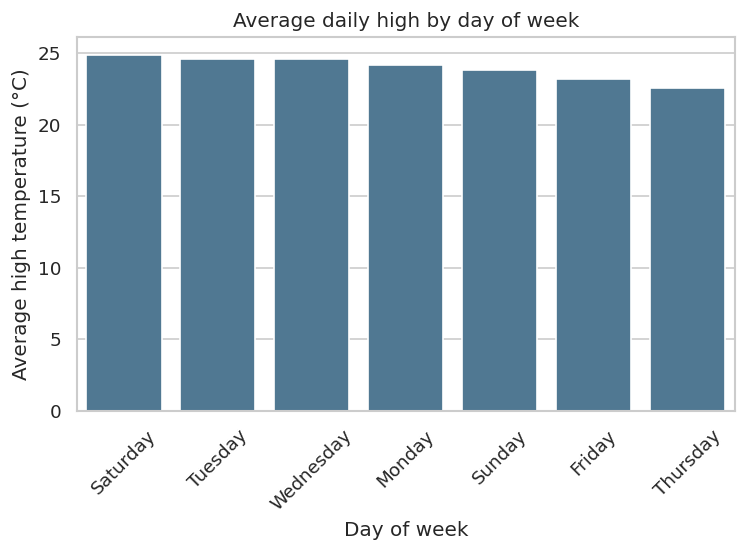

In [10]:
ax = sns.barplot(
    data=weekday_summary,
    x="day_name",
    y="average_high_c",
    color="#457b9d",
)
ax.set_title("Average daily high by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average high temperature (°C)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 7. A compact correlation view ⚠️

Correlation can summarize linear association, but it is sensitive to sample size, outliers,
and the range of variables. Treat this as a question generator, not as a final conclusion.


### 🧭 Syntax first: Correlation tables and heatmaps

Read the pattern before running the example. The names in the pattern are placeholders.

```python
numeric_df.corr(method="pearson", min_periods=1)

sns.heatmap(
    correlation_table,
    annot=True,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
)
```

Documentation: [DataFrame.corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) · [heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)


In [11]:
numeric_weather = weather[["temp_max_c", "temp_min_c", "precipitation_mm", "wind_max_kmh"]]
correlation_table = numeric_weather.corr().round(2)
correlation_table


Out[0]: 
                  temp_max_c  temp_min_c  precipitation_mm  wind_max_kmh
temp_max_c              1.00       -0.54             -0.13         -0.14
temp_min_c             -0.54        1.00              0.33          0.52
precipitation_mm       -0.13        0.33              1.00          0.28
wind_max_kmh           -0.14        0.52              0.28          1.00


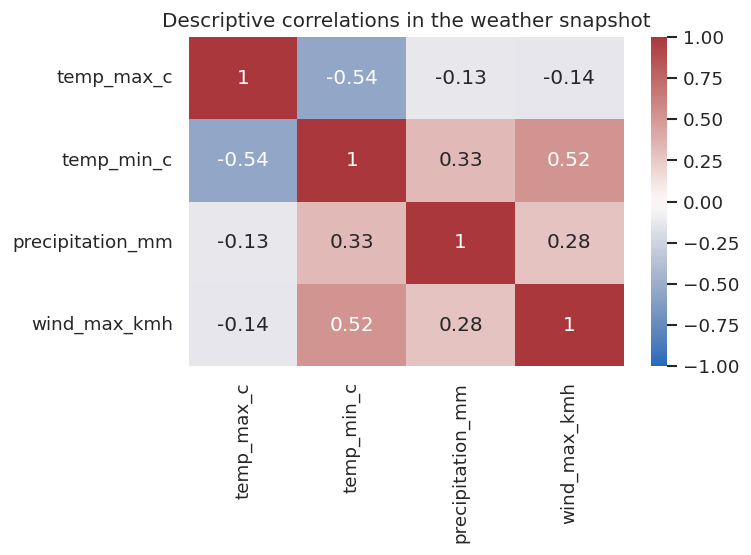

In [12]:
sns.heatmap(correlation_table, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Descriptive correlations in the weather snapshot")
plt.tight_layout()
plt.show()


> 💭 **Quick thought question:** Which cells in this heatmap could be unstable because of the small sample or the many zero-precipitation days?


## 8. Chart communication checklist ✅

Before sharing a chart, check:

- Is the question visible in the title?
- Are units and time periods clear?
- Are counts, rates, and denominators distinguished?
- Can a reader identify the comparison groups?
- Does the interpretation stay within the evidence?
- Is the chart readable in grayscale or for a color-vision deficiency?


## Comprehensive exercises 📝

For every exercise, show the summary table first. Then create a chart with a title, axis labels,
and a two- or three-sentence interpretation that includes one limitation.


### Exercise 1: Hottest and coldest days

Create a table containing the three hottest and three coldest days. Visualize the result with a chart that makes the comparison easy to read.


In [ ]:
# Write your solution here.


### Exercise 2: Rainfall as count and amount

Create one summary of the number of rainy days and another summary of total precipitation. Choose charts that make clear why these are different measures.


In [ ]:
# Write your solution here.


### Exercise 3: Windy versus calm days

Define a transparent rule for a windy day. Compare the temperature range on windy and non-windy days with a table and a suitable chart.


In [ ]:
# Write your solution here.


### Exercise 4: Chart critique

Create one misleading version of a temperature chart by making a poor design choice, then fix it. Explain exactly why the revised version communicates better.


In [ ]:
# Write your solution here.


### Exercise 5: Your own question

Ask one question that would matter to an outdoor-events manager, delivery company, or facilities team. Answer it with a table, a chart, and one limitation.


In [ ]:
# Write your solution here.


## Summary ✅

Effective visualization is a reasoning process, not only a plotting command:

1. Start with a question and a summary table.
2. Match the chart to the variable types and comparison.
3. Label units, groups, and denominators.
4. Inspect the chart for misleading scales or clutter.
5. Interpret the pattern without claiming more than the data supports.
